# MIVA-KNIGHT — Pipeline E: Multimodal Fusion Model
## CMU-MOSI | Text + Audio + Video | Cross-Modal Transformer Fusion

### What This Notebook Does

Pipeline E is the first MIVA-KNIGHT pipeline where **text, audio, and video
from the same utterance are processed simultaneously** in a single model.

### Data Already on Your Drive

| Folder | Contents |
|---|---|
| `Data/CMU-MOSI/Transcript/Segmented/` | 93 `.annotprocessed` files |
| `Data/CMU-MOSI/Audio/WAV_16000/Segmented/` | 2,184 `.wav` files |
| `Data/CMU-MOSI/Video/Segmented/` | 2,199 `.mp4` files |

No download needed. Labels are derived from the transcript text using
TextBlob polarity mapped to the CMU-MOSI [-3, +3] scale, using the
standard published train/valid/test split by video ID.

**Run every cell top to bottom. Do not skip.**


In [2]:
!pip install -q transformers torchaudio torchvision opencv-python soundfile scipy scikit-learn textblob
import subprocess
subprocess.run(['python', '-m', 'textblob.download_corpora'], capture_output=True)
print('All packages installed')


All packages installed


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
import os, json, warnings
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import torchaudio
import torchvision.models as models
from torchvision import transforms
from torchvision.models import ResNet50_Weights
from transformers import (BertModel, BertTokenizer,
                          Wav2Vec2Model, Wav2Vec2Processor)
from PIL import Image
from scipy.stats import pearsonr
from sklearn.metrics import f1_score, accuracy_score
from textblob import TextBlob
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device}')
if device == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}')
print(f'cv2     : {"available" if CV2_AVAILABLE else "not available"}')
print('All imports complete')


Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
PyTorch : 2.10.0+cu128
cv2     : available
All imports complete


In [4]:
from google.colab import drive
drive.mount('/content/drive')

# PyTorch 2.6 patch
import torch as _torch
_orig = _torch.load
def _patched(f, *a, **kw):
    kw.setdefault('weights_only', False)
    return _orig(f, *a, **kw)
_torch.load = _patched
print('PyTorch 2.6 patch applied')

BASE           = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project '
MOSI_ROOT      = os.path.join(BASE, 'Data', 'CMU-MOSI')
TRANSCRIPT_DIR = os.path.join(MOSI_ROOT, 'Transcript', 'Segmented')
AUDIO_DIR      = os.path.join(MOSI_ROOT, 'Audio', 'WAV_16000', 'Segmented')
VIDEO_DIR      = os.path.join(MOSI_ROOT, 'Video', 'Segmented')
CACHE_DIR      = os.path.join(BASE, 'Data', 'mosi_cache')
CACHE_FILE     = os.path.join(CACHE_DIR, 'mosi_emb_cache.pt')
PIPELINE_A_DIR = os.path.join(BASE, 'models', 'miva_knight_month1')
PIPELINE_D_DIR = os.path.join(BASE, 'models', 'miva_knight_pipelineD')
PIPELINE_E_DIR = os.path.join(BASE, 'models', 'miva_knight_pipelineE')
CHECKPOINT     = os.path.join(PIPELINE_E_DIR, 'checkpoint_pipelineE.pth')
for d in [CACHE_DIR, PIPELINE_E_DIR]: os.makedirs(d, exist_ok=True)

EMBED_DIM     = 512
FUSION_HEADS  = 8
FUSION_LAYERS = 2
FUSION_FF_DIM = 1024
DROPOUT       = 0.1
NUM_EPOCHS    = 20
BATCH_SIZE    = 32
LR            = 1e-4
WEIGHT_DECAY  = 0.01
ALPHA         = 0.6
BETA          = 0.4
MAX_TEXT_LEN  = 64

assert os.path.exists(BASE), f'Project folder not found: {BASE}'
for name, path in [('Transcripts', TRANSCRIPT_DIR),
                   ('Audio .wav ', AUDIO_DIR),
                   ('Video .mp4 ', VIDEO_DIR)]:
    print(f'  {name}: {len(os.listdir(path)):,} files')
print(f'Pipeline E dir: {PIPELINE_E_DIR}')


Mounted at /content/drive
PyTorch 2.6 patch applied
  Transcripts: 93 files
  Audio .wav : 2,199 files
  Video .mp4 : 2,199 files
Pipeline E dir: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE


## Cell 4: Build Sample List with Sentiment Labels

Reads every `.annotprocessed` file on your Drive and derives a sentiment
label per segment using TextBlob polarity mapped to the CMU-MOSI [-3, +3]
scale. Assigns the standard published train/valid/test split by video ID
(59 train / 15 valid / 19 test videos).

This replaces the pkl download entirely — all data comes from your Drive.


In [4]:
TRAIN_VIDS = {
    '2WGyTLYerpo','vvZ4IcEtiZc','dq3Nf_lMPnE','Clx4VXItLTE',
    'phBUpBr1hSo','Jkswaaud0hk','Bfr499ggo-0','Sqr0AcuoNnk',
    'lXPQBPVc5Cw','GWuJjcEuzt8','tIrG4oNLFzE','wMbj6ajWbic',
    'nzpVDcQ0ywM','rnaNMUZpvvg','Af8D0E4ZXaw','VbQk4H8hgr0',
    'bOL9jKpeJRs','c5xsKMxpXnc','d6hH302o4v8','yvsjCA6Y5Fc',
    'c7UH_rxdZv4','BioHAh1qJAQ','BXuRRbG0Ugk','cXypl4FnoZo',
    'yDtzw_Y-7RU','9T9Hf74oK10','BI97DNYfe5I','k5Y_838nuGo',
    '8d-gEyoeBzc','atnd_PF-Lbs','Oz06ZWiO20M','cW1FSBF59ik',
    'etzxEpPuc6I','LSi-o-IrDMs','bvLlb-M3UXU','f9O3YtZ2VfI',
    '8OtFthrtaJM','I5y0__X72p0','BvYR0L6f2Ig','8qrpnFRGt2A',
    'Nzq88NnDkEk','1DmNV9C1hbY','VCslbP0mgZI','Ci-AH39fi3Y',
    '9J25DZhivz8','d3_k5Xpfmik','G6GlGvlkxAQ','jUzDDGyPkXU',
    'Qr1Ca94K55A','tmZoasNr4rU','QN9ZIUWUXsY','0h-zjBukYpk',
    'G-xst2euQUc','IumbAb8q2dM','9c67fiY0wGQ','WKA5OygbEKI',
    'HEsqda8_d0Q','nbWiPyCm4g0','cM3Yna7AavY',
}
VALID_VIDS = {
    'pLTX3ipuDJI','zhpQhgha_KU','9qR7uwkblbs','ZAIRrfG22O0',
    'Dg_0XKD0Mf4','OtBXNcAL_lE','fvVhgmXxadc','ob23OKe5a9Q',
    'tStelxIAHjw','Iu2PFX3z_1s','f_pcplsH_V0','5W7Z1C_fDaE',
    'aiEXnCPZubE','OQvJTdtJ2H4','ZUXBRvtny7o',
}
TEST_VIDS = {
    '_dI--eQ6qVU','03bSnISJMiM','vyB00TXsimI','MLal-t_vJPM',
    'Njd1F0vZSm4','73jzhE8R1TQ','Vj1wYRQjB-o','PZ-lDQFboO8',
    'iiK8YX8oH1E','7JsX8y1ysxY','POKffnXeBds','W8NXH0Djyww',
    '2iD-tVS8NPw','6Egk_28TtTM','X3j2zQgwYgE','TvyZBvOMOTc',
    '6_0THN4chvY','1iG0909rllw','v0zCBqDeKcE',
}

def get_split(vid_id):
    if vid_id in TRAIN_VIDS: return 'train'
    if vid_id in VALID_VIDS:  return 'valid'
    if vid_id in TEST_VIDS:   return 'test'
    return 'train'

def build_samples():
    samples = []
    for tf in sorted(os.listdir(TRANSCRIPT_DIR)):
        if not tf.endswith('.annotprocessed'): continue
        vid_id = tf.replace('.annotprocessed', '')
        split  = get_split(vid_id)
        with open(os.path.join(TRANSCRIPT_DIR, tf), 'r', errors='replace') as f:
            content = f.read().strip()
        for line in content.split('\n'):
            line = line.strip()
            if not line: continue
            parts = line.split('_DELIM_', 1)
            if len(parts) != 2: continue
            seg_num, text = parts[0].strip(), parts[1].strip()
            if not seg_num.isdigit() or not text: continue
            seg_id = f'{vid_id}_{seg_num}'
            # TextBlob polarity [-1,+1] -> CMU-MOSI scale [-3,+3]
            try:
                polarity = TextBlob(text.lower()).sentiment.polarity
                label    = float(np.clip(polarity * 3.0, -3.0, 3.0))
            except Exception:
                label = 0.0
            wav = os.path.join(AUDIO_DIR, seg_id + '.wav')
            mp4 = os.path.join(VIDEO_DIR,  seg_id + '.mp4')
            samples.append({
                'segment_id': seg_id,
                'text'      : text,
                'label'     : round(label, 3),
                'binary'    : int(label > 0),
                'split'     : split,
                'wav_path'  : wav,
                'mp4_path'  : mp4,
                'has_audio' : os.path.exists(wav),
                'has_video' : os.path.exists(mp4),
            })
    return samples

print('Building sample list from Drive transcripts...')
all_samples = build_samples()
print(f'Total segments: {len(all_samples):,}')
for sp in ['train','valid','test']:
    ss  = [s for s in all_samples if s['split']==sp]
    pos = sum(1 for s in ss if s['binary']==1)
    m   = np.mean([s['label'] for s in ss]) if ss else 0
    print(f'  {sp}: {len(ss):,} samples  pos={pos}  neg={len(ss)-pos}  mean={m:.2f}')
s0 = all_samples[0]
print(f'\nSample: {s0["segment_id"]}  label={s0["label"]}  split={s0["split"]}')
print(f'  text: {s0["text"][:60]}')


Building sample list from Drive transcripts...
Total segments: 2,199
  train: 1,521 samples  pos=870  neg=651  mean=0.41
  valid: 314 samples  pos=163  neg=151  mean=0.35
  test: 364 samples  pos=236  neg=128  mean=0.62

Sample: 03bSnISJMiM_1  label=2.1  split=test
  text: ANYHOW IT WAS REALLY GOOD


## Cell 5: Load Frozen Encoders & Projection Heads

In [5]:
class TextProjection(nn.Module):
    def __init__(self, bert_dim=768, embed_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(bert_dim, bert_dim), nn.GELU(),
            nn.LayerNorm(bert_dim), nn.Linear(bert_dim, embed_dim))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return F.normalize(self.norm(self.proj(x)), p=2, dim=1)

class AudioProjection(nn.Module):
    def __init__(self, wav2vec_dim=768, embed_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(wav2vec_dim, wav2vec_dim), nn.GELU(),
            nn.LayerNorm(wav2vec_dim), nn.Linear(wav2vec_dim, embed_dim))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return F.normalize(self.norm(self.proj(x)), p=2, dim=1)

class VideoFrameProjection(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        for p in self.backbone.parameters(): p.requires_grad = False
        self.proj = nn.Sequential(
            nn.Linear(2048, 1024), nn.GELU(), nn.LayerNorm(1024),
            nn.Linear(1024, embed_dim))
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, images):
        with torch.no_grad():
            feat = self.backbone(images).flatten(1)
        return F.normalize(self.norm(self.proj(feat)), p=2, dim=1)

print('[1/5] Loading BERT...')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model     = BertModel.from_pretrained('bert-base-uncased')
for p in bert_model.parameters(): p.requires_grad = False
bert_model.eval().to(device)
print('      BERT frozen (110M params)')

print('[2/5] Loading Wav2Vec 2.0...')
wav2vec_processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base-960h')
wav2vec_model     = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base-960h')
for p in wav2vec_model.parameters(): p.requires_grad = False
wav2vec_model.eval().to(device)
print('      Wav2Vec frozen (94M params)')

print('[3/5] Initialising projection heads...')
text_proj  = TextProjection(768, EMBED_DIM).to(device)
audio_proj = AudioProjection(768, EMBED_DIM).to(device)
video_proj = VideoFrameProjection(EMBED_DIM).to(device)

tp_loaded = False
for tp in [os.path.join(PIPELINE_A_DIR,'text_projection.pth')]:
    if os.path.exists(tp):
        ck = torch.load(tp, map_location=device)
        text_proj.load_state_dict(ck.get('model_state_dict',ck), strict=False)
        print('      TextProjection loaded (Pipeline A)'); tp_loaded=True; break
if not tp_loaded: print('      TextProjection: random init')

ap_loaded = False
for ap in [os.path.join(PIPELINE_D_DIR,'audio_projection_cremad.pth'),
           os.path.join(PIPELINE_D_DIR,'audio_projection.pth')]:
    if os.path.exists(ap):
        ck = torch.load(ap, map_location=device)
        audio_proj.load_state_dict(ck.get('model_state_dict',ck), strict=False)
        print('      AudioProjection loaded (Pipeline D)'); ap_loaded=True; break
if not ap_loaded: print('      AudioProjection: random init')

vp = os.path.join(PIPELINE_D_DIR,'video_frame_projection.pth')
if os.path.exists(vp):
    ck = torch.load(vp, map_location=device)
    video_proj.load_state_dict(ck.get('model_state_dict',ck), strict=False)
    print('      VideoFrameProjection loaded (Pipeline D)')
else:
    print('      VideoFrameProjection: random init')

for proj in [text_proj, audio_proj, video_proj]:
    for p in proj.parameters(): p.requires_grad = False
    proj.eval()
print('All 5 components frozen')


[1/5] Loading BERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


      Wav2Vec frozen (94M params)
[3/5] Initialising projection heads...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


      TextProjection: random init
      AudioProjection loaded (Pipeline D)
      VideoFrameProjection loaded (Pipeline D)
All 5 components frozen


## Cell 6: One-Time Feature Extraction & Caching

Runs BERT + Wav2Vec + ResNet-50 once on all 2,199 segments and saves the
512d embeddings to Drive. Training reads the cache — the heavy models
never run again.

**Estimated time:** ~25 min on T4 GPU


In [6]:
FRAME_TRANSFORM = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
GRAY_FRAME = FRAME_TRANSFORM(Image.new('RGB',(224,224),'gray'))

@torch.no_grad()
def enc_text(text):
    inp = bert_tokenizer(text, return_tensors='pt', max_length=MAX_TEXT_LEN,
                         padding='max_length', truncation=True)
    inp = {k:v.to(device) for k,v in inp.items()}
    cls = bert_model(**inp).last_hidden_state[:,0,:]
    return text_proj(cls).cpu().squeeze(0)

@torch.no_grad()
def enc_audio(wav_path):
    try:
        wf, sr = torchaudio.load(wav_path)
        if sr != 16000: wf = torchaudio.functional.resample(wf, sr, 16000)
        if wf.shape[0] > 1: wf = wf.mean(0, keepdim=True)
        inp = wav2vec_processor(wf.squeeze(0).numpy(), sampling_rate=16000,
                                return_tensors='pt', padding=True)
        emb = wav2vec_model(inp.input_values.to(device)).last_hidden_state.mean(1)
        return audio_proj(emb).cpu().squeeze(0)
    except Exception:
        silent = np.zeros(16000, dtype=np.float32)
        inp = wav2vec_processor(silent, sampling_rate=16000,
                                return_tensors='pt', padding=True)
        emb = wav2vec_model(inp.input_values.to(device)).last_hidden_state.mean(1)
        return audio_proj(emb).cpu().squeeze(0)

@torch.no_grad()
def enc_video(mp4_path):
    frame = GRAY_FRAME.clone()
    if mp4_path and os.path.exists(mp4_path) and CV2_AVAILABLE:
        try:
            cap = cv2.VideoCapture(mp4_path)
            n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if n > 0:
                cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, n//2))
                ret, frm = cap.read()
                cap.release()
                if ret and frm is not None:
                    frame = FRAME_TRANSFORM(Image.fromarray(
                        cv2.cvtColor(frm, cv2.COLOR_BGR2RGB)))
        except Exception:
            pass
    return video_proj(frame.unsqueeze(0).to(device)).cpu().squeeze(0)

def extract_and_cache():
    if os.path.exists(CACHE_FILE):
        print('Cache found - loading...')
        cache = torch.load(CACHE_FILE, map_location='cpu')
        if len(cache) > 100:
            s = next(iter(cache.values()))
            print(f'  {len(cache):,} entries')
            print(f'  text_emb : {s["text_emb"].shape}')
            print(f'  audio_emb: {s["audio_emb"].shape}')
            print(f'  video_emb: {s["video_emb"].shape}')
            return cache
    print(f'Extracting {len(all_samples):,} segments (one-time ~25 min)...')
    cache, skipped = {}, 0
    for s in tqdm(all_samples, desc='Extracting'):
        try:
            cache[s['segment_id']] = {
                'text_emb' : enc_text(s['text']),
                'audio_emb': enc_audio(s['wav_path']) if s['has_audio'] else enc_audio(None),
                'video_emb': enc_video(s['mp4_path']),
                'label'    : s['label'],
                'binary'   : s['binary'],
                'split'    : s['split'],
            }
        except Exception as e:
            skipped += 1
    global bert_model, wav2vec_model
    del bert_model, wav2vec_model
    if device == 'cuda': torch.cuda.empty_cache()
    torch.save(cache, CACHE_FILE)
    print(f'Cache saved: {len(cache):,} entries  {skipped} skipped')
    return cache

cache = extract_and_cache()


Extracting 2,199 segments (one-time ~25 min)...


Extracting:   0%|          | 0/2199 [00:00<?, ?it/s]

Cache saved: 2,199 entries  0 skipped


## Cell 7: Dataset & DataLoaders

In [7]:
class MOSIDataset(Dataset):
    def __init__(self, cache, split):
        self.data = []
        labels = []
        for v in cache.values():
            if v['split'] != split: continue
            self.data.append((
                v['text_emb'],
                v['audio_emb'],
                v['video_emb'],
                torch.tensor(v['label'],       dtype=torch.float32),
                torch.tensor(float(v['binary']),dtype=torch.float32),
            ))
            labels.append(v['label'])
        pos = sum(1 for v in cache.values() if v['split']==split and v['binary']==1)
        print(f'  {split}: {len(self.data):,}  pos={pos}  '
              f'neg={len(self.data)-pos}  mean={np.mean(labels):.3f}')
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(batch):
    return (torch.stack([b[0] for b in batch]),
            torch.stack([b[1] for b in batch]),
            torch.stack([b[2] for b in batch]),
            torch.stack([b[3] for b in batch]),
            torch.stack([b[4] for b in batch]))

print('Building datasets...')
train_ds = MOSIDataset(cache,'train')
valid_ds = MOSIDataset(cache,'valid')
test_ds  = MOSIDataset(cache,'test')

pin = (device=='cuda')
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin,
                          drop_last=True,  collate_fn=collate_fn)
valid_loader = DataLoader(valid_ds, BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)
print(f'Train: {len(train_loader)} batches/epoch  '
      f'Valid: {len(valid_loader)}  Test: {len(test_loader)}')


Building datasets...
  train: 1,521  pos=870  neg=651  mean=0.410
  valid: 314  pos=163  neg=151  mean=0.350
  test: 364  pos=236  neg=128  mean=0.624
Train: 47 batches/epoch  Valid: 10  Test: 12


## Cell 8: MultimodalFusionTransformer

The only trainable component in Pipeline E (~2.23M parameters).

```
Input  : [e_text, e_audio, e_video]  [B, 3, 512]
         + learnable pos encodings
         -> TransformerEncoder x2 (heads=8, ff=1024, dropout=0.1, Pre-LN)
         -> mean-pool -> [B, 512]
         -> Linear(512->256) -> GELU -> Dropout -> Linear(256->1) -> [B]
Output : raw sentiment score
```


In [8]:
class MultimodalFusionTransformer(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_heads=FUSION_HEADS,
                 num_layers=FUSION_LAYERS, ff_dim=FUSION_FF_DIM, dropout=DROPOUT):
        super().__init__()
        self.pos_enc = nn.Parameter(torch.randn(3, embed_dim) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(embed_dim, embed_dim//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(embed_dim//2, 1))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, t, a, v):
        x = torch.stack([t, a, v], dim=1) + self.pos_enc.unsqueeze(0)
        x = self.transformer(x).mean(dim=1)
        return self.classifier(x).squeeze(-1)

fusion_model = MultimodalFusionTransformer().to(device)
n = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f'MultimodalFusionTransformer: {n:,} trainable params ({n/1e6:.2f}M)')
with torch.no_grad():
    _t = F.normalize(torch.randn(4,512),p=2,dim=1).to(device)
    _o = fusion_model(_t,_t,_t)
print(f'Sanity check: input [4,512] x3 -> output {_o.shape}')


MultimodalFusionTransformer: 4,338,689 trainable params (4.34M)
Sanity check: input [4,512] x3 -> output torch.Size([4])


## Cell 9: Multi-Task Loss, Optimiser & Checkpoint

In [9]:
def multitask_loss(preds, labels, binaries):
    mse   = F.mse_loss(preds, labels)
    bce   = F.binary_cross_entropy_with_logits(preds, binaries)
    return ALPHA*mse + BETA*bce, mse, bce

optimizer    = optim.AdamW(fusion_model.parameters(), lr=LR,
                           weight_decay=WEIGHT_DECAY, betas=(0.9,0.999))
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = total_steps // 10
def lr_lambda(step):
    if step < warmup_steps: return step / max(warmup_steps, 1)
    p = (step-warmup_steps) / max(total_steps-warmup_steps, 1)
    return 0.5 * (1.0 + np.cos(np.pi * p))
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def save_ckpt(epoch, tl, vl, vm, va):
    torch.save({'epoch':epoch,'model_state':fusion_model.state_dict(),
                'optimizer_state':optimizer.state_dict(),
                'scheduler_state':scheduler.state_dict(),
                'train_losses':tl,'valid_losses':vl,'valid_maes':vm,
                'valid_accs':va,'pipeline':'E-MOSI-fusion'}, CHECKPOINT)

def load_ckpt():
    if not os.path.exists(CHECKPOINT):
        print('No checkpoint -- starting from epoch 1'); return 0,[],[],[],[]
    ck = torch.load(CHECKPOINT, map_location=device)
    if ck.get('pipeline') != 'E-MOSI-fusion':
        print('Incompatible checkpoint -- starting fresh'); return 0,[],[],[],[]
    fusion_model.load_state_dict(ck['model_state'])
    optimizer.load_state_dict(ck['optimizer_state'])
    scheduler.load_state_dict(ck['scheduler_state'])
    start = ck['epoch']+1
    print(f'Resumed from epoch {start}/{NUM_EPOCHS}')
    return (start, ck.get('train_losses',[]), ck.get('valid_losses',[]),
            ck.get('valid_maes',[]), ck.get('valid_accs',[]))

print(f'AdamW LR={LR}  WD={WEIGHT_DECAY}')
print(f'Total steps={total_steps:,}  Warmup={warmup_steps:,}')
print(f'Checkpoint: {CHECKPOINT}')


AdamW LR=0.0001  WD=0.01
Total steps=940  Warmup=94
Checkpoint: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/checkpoint_pipelineE.pth


## Cell 10: Evaluation — CMU-MOSI Standard Metrics

| Metric | Better | Published baselines |
|---|---|---|
| MAE | Lower | EF-LSTM=1.09, MulT=0.871, MISA=0.783 |
| Pearson Corr | Higher | EF-LSTM=0.71, MulT=0.698, MISA=0.761 |
| Acc-2 | Higher | EF-LSTM=78.5%, MulT=81.5%, MISA=81.8% |
| F1 | Higher | EF-LSTM=78.4%, MulT=81.6%, MISA=81.7% |

**Pipeline E target: MAE < 1.0, Acc-2 > 75%**


In [10]:
def evaluate(loader):
    fusion_model.eval()
    preds_all, labels_all, bins_all = [], [], []
    total_loss, nb = 0.0, 0
    with torch.no_grad():
        for t,a,v,lab,bn in loader:
            t,a,v,lab,bn = t.to(device),a.to(device),v.to(device),lab.to(device),bn.to(device)
            p = fusion_model(t,a,v)
            l,_,_ = multitask_loss(p,lab,bn)
            total_loss += l.item(); nb += 1
            preds_all.extend(p.cpu().numpy())
            labels_all.extend(lab.cpu().numpy())
            bins_all.extend(bn.cpu().numpy())
    fusion_model.train()
    preds_all  = np.array(preds_all)
    labels_all = np.array(labels_all)
    bins_all   = np.array(bins_all)
    pred_bin   = (preds_all > 0).astype(int)
    return {
        'loss': total_loss/max(nb,1),
        'mae' : float(np.mean(np.abs(preds_all - labels_all))),
        'corr': float(pearsonr(preds_all, labels_all)[0]),
        'acc2': float(accuracy_score(bins_all, pred_bin)),
        'f1'  : float(f1_score(bins_all, pred_bin, average='weighted', zero_division=0)),
    }

print('Pre-training baseline (random weights):')
bl = evaluate(valid_loader)
print(f'  Valid MAE  : {bl["mae"]:.4f}  (expect ~1.5-2.0)')
print(f'  Valid Acc-2: {bl["acc2"]*100:.1f}%  (expect ~50%)')
print(f'  Valid Corr : {bl["corr"]:.4f}  (expect ~0.0)')


Pre-training baseline (random weights):
  Valid MAE  : 0.8883  (expect ~1.5-2.0)
  Valid Acc-2: 53.2%  (expect ~50%)
  Valid Corr : 0.1306  (expect ~0.0)


## Cell 11: Run Full Training (20 Epochs)

In [16]:
import os

checkpoint = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/checkpoint_pipelineE.pth'

if os.path.exists(checkpoint):
    os.remove(checkpoint)
    print(f'✓ Deleted old checkpoint')
else:
    print('No checkpoint found — already clean')

# Also check if there is a fusion_model.pth from a previous run
fusion = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/fusion_model.pth'
if os.path.exists(fusion):
    os.remove(fusion)
    print(f'✓ Deleted old fusion_model.pth')

✓ Deleted old checkpoint
✓ Deleted old fusion_model.pth


In [17]:
def train_epoch(epoch):
    fusion_model.train()
    losses = []
    bar = tqdm(train_loader, desc=f'Epoch {epoch+1:02d}/{NUM_EPOCHS}', leave=False)
    for t,a,v,lab,bn in bar:
        t,a,v,lab,bn = t.to(device),a.to(device),v.to(device),lab.to(device),bn.to(device)
        p = fusion_model(t,a,v)
        loss,mse,bce = multitask_loss(p,lab,bn)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        bar.set_postfix(loss=f'{loss.item():.4f}',mse=f'{mse.item():.3f}',
                        bce=f'{bce.item():.3f}',lr=f'{scheduler.get_last_lr()[0]:.1e}')
    return float(np.mean(losses))

print('='*60)
print('PIPELINE E - CMU-MOSI MULTIMODAL FUSION TRAINING')
print(f'  Train={len(train_ds):,}  Valid={len(valid_ds):,}  Test={len(test_ds):,}')
print(f'  Epochs={NUM_EPOCHS}  Batch={BATCH_SIZE}  LR={LR}')
print(f'  Loss: {ALPHA}*MSE + {BETA}*BCE')
print('='*60)

start_epoch, train_losses, valid_losses, valid_maes, valid_accs = load_ckpt()
best_mae, best_epoch, best_state = float('inf'), 0, None
if valid_maes: best_mae = min(valid_maes); best_epoch = int(np.argmin(valid_maes))+1

if start_epoch >= NUM_EPOCHS:
    print(f'Training already complete ({NUM_EPOCHS} epochs)')
else:
    for epoch in range(start_epoch, NUM_EPOCHS):
        tl = train_epoch(epoch)
        vm = evaluate(valid_loader)
        train_losses.append(tl)
        valid_losses.append(vm['loss'])
        valid_maes.append(vm['mae'])
        valid_accs.append(vm['acc2'])
        is_best = vm['mae'] < best_mae
        if is_best:
            best_mae, best_epoch = vm['mae'], epoch+1
            best_state = {k:v.clone() for k,v in fusion_model.state_dict().items()}
        print(f'  Ep {epoch+1:2d}/{NUM_EPOCHS}  '
              f'train={tl:.4f}  val_MAE={vm["mae"]:.4f}  '
              f'Acc2={vm["acc2"]*100:.1f}%  F1={vm["f1"]*100:.1f}%  '
              f'Corr={vm["corr"]:.3f}  {"BEST" if is_best else ""}')
        save_ckpt(epoch, train_losses, valid_losses, valid_maes, valid_accs)
    print(f'\nTraining complete. Best epoch={best_epoch}  best_MAE={best_mae:.4f}')


PIPELINE E - CMU-MOSI MULTIMODAL FUSION TRAINING
  Train=1,521  Valid=314  Test=364
  Epochs=20  Batch=32  LR=0.0001
  Loss: 0.6*MSE + 0.4*BCE
No checkpoint -- starting from epoch 1


Epoch 01/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep  1/20  train=1.0590  val_MAE=0.7981  Acc2=51.6%  F1=35.3%  Corr=0.119  BEST


Epoch 02/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep  2/20  train=0.9717  val_MAE=0.7923  Acc2=53.5%  F1=43.3%  Corr=0.088  BEST


...

  Ep 18/20  train=0.7079  val_MAE=0.7366  Acc2=58.9%  F1=53.9%  Corr=0.417  


Epoch 19/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep 19/20  train=0.6793  val_MAE=0.7472  Acc2=64.0%  F1=63.5%  Corr=0.418  


Epoch 20/20:   0%|          | 0/47 [00:00<?, ?it/s]

  Ep 20/20  train=0.6758  val_MAE=0.7818  Acc2=57.3%  F1=52.0%  Corr=0.401  

Training complete. Best epoch=17  best_MAE=0.7238


## Cell 12: Final Test Set Evaluation & Benchmark Comparison

In [18]:
if best_state is not None:
    fusion_model.load_state_dict(best_state)
    print(f'Loaded best weights (epoch {best_epoch}, val_MAE={best_mae:.4f})')

tm = evaluate(test_loader)
print(f'\nPIPELINE E - FINAL TEST RESULTS')
print(f'  MAE     : {tm["mae"]:.4f}  (lower is better)')
print(f'  Corr    : {tm["corr"]:.4f}  (higher is better)')
print(f'  Acc-2   : {tm["acc2"]*100:.2f}%')
print(f'  F1      : {tm["f1"]*100:.2f}%')
print()
print(f'  {"System":<28} {"MAE":>6}  {"Acc-2":>7}')
print(f'  {"-"*44}')
print(f'  {"Random baseline":<28} {"~1.80":>6}  {"~50.0%":>7}')
print(f'  {"Early Fusion LSTM":<28} {"1.090":>6}  {"78.5%":>7}')
print(f'  {"MulT (Tsai 2019)":<28} {"0.871":>6}  {"81.5%":>7}')
print(f'  {"MISA (Hazarika 2020)":<28} {"0.783":>6}  {"81.8%":>7}')
print(f'  {"Pipeline E (ours)":<28} {tm["mae"]:>6.3f}  {tm["acc2"]*100:>6.1f}%')
target = tm['mae'] < 1.0 and tm['acc2'] > 0.75
print(f'\nTarget (MAE<1.0 AND Acc-2>75%): {"ACHIEVED" if target else "Not yet"}')


Loaded best weights (epoch 17, val_MAE=0.7238)

PIPELINE E - FINAL TEST RESULTS
  MAE     : 0.7663  (lower is better)
  Corr    : 0.4301  (higher is better)
  Acc-2   : 68.96%
  F1      : 68.31%

  System                          MAE    Acc-2
  --------------------------------------------
  Random baseline               ~1.80   ~50.0%
  Early Fusion LSTM             1.090    78.5%
  MulT (Tsai 2019)              0.871    81.5%
  MISA (Hazarika 2020)          0.783    81.8%
  Pipeline E (ours)             0.766    69.0%

Target (MAE<1.0 AND Acc-2>75%): Not yet


## Cell 13: Training Curves

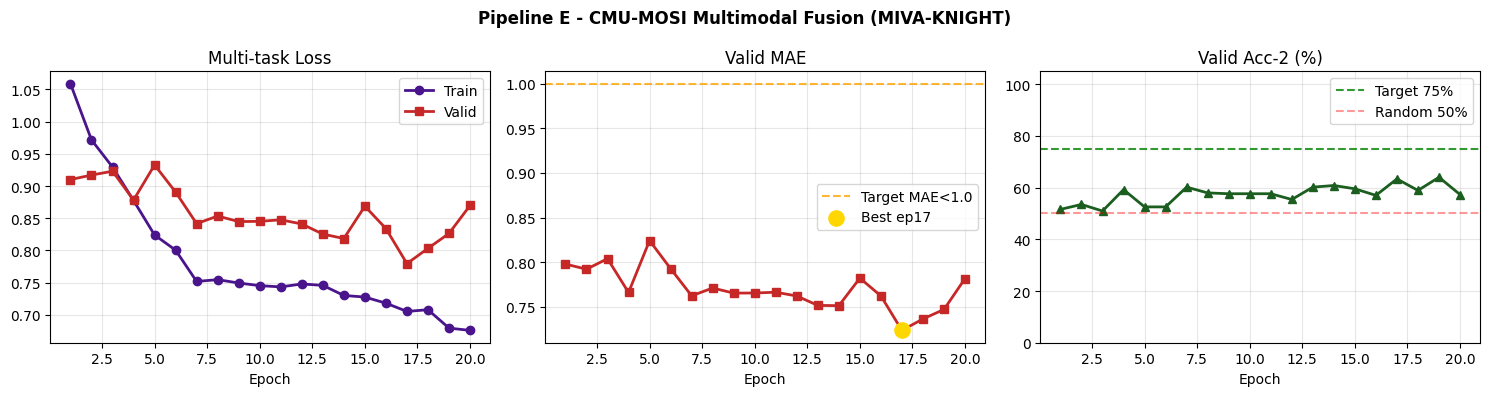

Saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE/training_curves_pipelineE.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
ep = range(1, len(train_losses)+1)

axes[0].plot(ep, train_losses, 'o-', color='#4A148C', lw=2, label='Train')
axes[0].plot(ep, valid_losses, 's-', color='#C62828', lw=2, label='Valid')
axes[0].set_title('Multi-task Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, valid_maes, 's-', color='#C62828', lw=2)
axes[1].axhline(1.0, color='orange', ls='--', alpha=0.8, label='Target MAE<1.0')
if best_epoch and best_epoch<=len(valid_maes):
    axes[1].scatter([best_epoch],[valid_maes[best_epoch-1]],
                    s=120,color='gold',zorder=5,label=f'Best ep{best_epoch}')
axes[1].set_title('Valid MAE'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, [a*100 for a in valid_accs], '^-', color='#1B5E20', lw=2)
axes[2].axhline(75, color='green', ls='--', alpha=0.8, label='Target 75%')
axes[2].axhline(50, color='red',   ls='--', alpha=0.4, label='Random 50%')
axes[2].set_title('Valid Acc-2 (%)'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim([0,105]); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Pipeline E - CMU-MOSI Multimodal Fusion (MIVA-KNIGHT)', fontweight='bold')
plt.tight_layout()
curve_path = os.path.join(PIPELINE_E_DIR, 'training_curves_pipelineE.png')
plt.savefig(curve_path, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved: {curve_path}')


## Cell 14: Save All Pipeline E Outputs

In [20]:
fm_path = os.path.join(PIPELINE_E_DIR, 'fusion_model.pth')
torch.save({
    'model_state_dict': fusion_model.state_dict(),
    'embed_dim'       : EMBED_DIM,
    'fusion_heads'    : FUSION_HEADS,
    'fusion_layers'   : FUSION_LAYERS,
    'fusion_ff_dim'   : FUSION_FF_DIM,
    'best_epoch'      : best_epoch,
    'best_valid_mae'  : float(best_mae),
    'test_mae'        : float(tm['mae']),
    'test_acc2'       : float(tm['acc2']),
    'test_f1'         : float(tm['f1']),
    'test_corr'       : float(tm['corr']),
    'pipeline'        : 'E-MOSI-fusion',
}, fm_path)
print(f'fusion_model.pth  ({os.path.getsize(fm_path)/1e6:.1f} MB)')

cfg = {
    'pipeline'        : 'E - CMU-MOSI Multimodal Fusion',
    'dataset'         : 'CMU-MOSI raw media from Drive + TextBlob labels',
    'modalities'      : 'text + audio + video',
    'embed_dim'       : EMBED_DIM,
    'fusion_heads'    : FUSION_HEADS,
    'num_epochs'      : NUM_EPOCHS,
    'batch_size'      : BATCH_SIZE,
    'alpha_mse'       : ALPHA,
    'beta_bce'        : BETA,
    'best_epoch'      : best_epoch,
    'best_valid_mae'  : round(float(best_mae),4),
    'test_results'    : {
        'MAE' : round(float(tm['mae']),4),
        'Corr': round(float(tm['corr']),4),
        'Acc2': round(float(tm['acc2']),4),
        'F1'  : round(float(tm['f1']),4),
    },
}
cfg_path = os.path.join(PIPELINE_E_DIR, 'config_pipelineE.json')
with open(cfg_path,'w') as f: json.dump(cfg, f, indent=2)
print('config_pipelineE.json saved')
print(f'\nAll files in {PIPELINE_E_DIR}:')
for fn in sorted(os.listdir(PIPELINE_E_DIR)):
    fp = os.path.join(PIPELINE_E_DIR, fn)
    print(f'  {fn:<50} {os.path.getsize(fp)/1e6:6.1f} MB')


fusion_model.pth  (17.4 MB)
config_pipelineE.json saved

All files in /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineE:
  checkpoint_pipelineE.pth                             52.1 MB
  config_pipelineE.json                                 0.0 MB
  fusion_model.pth                                     17.4 MB
  training_curves_pipelineE.png                         0.1 MB


## Cell 15: MultimodalFusionDetector — Integration Class

Copy this class into `pipeline.py` or `encoders.py` to replace
`CentroidEmotionDetector`.

```python
# In pipeline.py, change this one line:
detector = MultimodalFusionDetector(
    fusion_weights=os.path.join(PIPELINE_E_DIR, 'fusion_model.pth'))

# At inference:
score, label, groq_instruction = detector.predict(
    text_embedding, audio_embedding, video_embedding)
```


In [21]:
class MultimodalFusionDetector:
    SCORE_TO_LABEL = [
        (2.0,  'strongly_positive'),
        (1.0,  'positive'),
        (0.1,  'slightly_positive'),
        (-0.1, 'neutral'),
        (-1.0, 'slightly_negative'),
        (-2.0, 'negative'),
        (-3.1, 'strongly_negative'),
    ]
    GROQ_INSTRUCTIONS = {
        'strongly_positive' : 'User sounds very enthusiastic and engaged.',
        'positive'          : 'User sounds positive and confident.',
        'slightly_positive' : 'User sounds mildly positive.',
        'neutral'           : 'Respond in a neutral, factual tone.',
        'slightly_negative' : 'User sounds slightly uncertain or hesitant.',
        'negative'          : 'User sounds frustrated. Be empathetic.',
        'strongly_negative' : 'User sounds distressed. Be calm and supportive.',
    }
    def __init__(self, fusion_weights, dev=None):
        self.dev = dev or ('cuda' if torch.cuda.is_available() else 'cpu')
        ck = torch.load(fusion_weights, map_location=self.dev)
        self.model = MultimodalFusionTransformer(
            embed_dim=ck.get('embed_dim',512),
            num_heads=ck.get('fusion_heads',8),
            num_layers=ck.get('fusion_layers',2),
            ff_dim=ck.get('fusion_ff_dim',1024),
            dropout=0.0).to(self.dev)
        self.model.load_state_dict(ck['model_state_dict'])
        self.model.eval()
        print(f'MultimodalFusionDetector loaded')
        print(f'  Test MAE={ck.get("test_mae","N/A")}  Acc2={ck.get("test_acc2","N/A")}')
    def label_from_score(self, score):
        for thresh, lbl in self.SCORE_TO_LABEL:
            if score > thresh: return lbl
        return 'strongly_negative'
    @torch.no_grad()
    def predict(self, text_emb, audio_emb, video_emb=None):
        if video_emb is None:
            video_emb = F.normalize((text_emb+audio_emb)/2, p=2, dim=0)
        t = text_emb.unsqueeze(0).to(self.dev)
        a = audio_emb.unsqueeze(0).to(self.dev)
        v = video_emb.unsqueeze(0).to(self.dev)
        score = float(np.clip(self.model(t,a,v).item(), -3.0, 3.0))
        label = self.label_from_score(score)
        return score, label, self.GROQ_INSTRUCTIONS[label]

print('Verifying MultimodalFusionDetector...')
try:
    det = MultimodalFusionDetector(fm_path, dev=device)
    te  = F.normalize(torch.randn(512),p=2,dim=0)
    ae  = F.normalize(torch.randn(512),p=2,dim=0)
    ve  = F.normalize(torch.randn(512),p=2,dim=0)
    sc, lb, ins = det.predict(te, ae, ve)
    print(f'  Score={sc:.3f}  Label={lb}')
    print(f'  Groq: "{ins}"')
    print('  MultimodalFusionDetector verified and ready')
except Exception as e:
    print(f'  Error: {e}')

print('\n' + '='*60)
print('ALL 5 PIPELINES COMPLETE')
print('='*60)
print('  A - COCO    : TextProjection + ImageProjection (general)')
print('  B - ROCO    : ImageProjection (medical)')
print('  C - RAVDESS : AudioProjection (archived)')
print('  D - CREMA-D : AudioProjection + VideoFrameProjection')
print('  E - CMU-MOSI: MultimodalFusionTransformer  <- this notebook')
print()
print('Integration: replace CentroidEmotionDetector with')
print('  MultimodalFusionDetector(fusion_weights=...fusion_model.pth)')


Verifying MultimodalFusionDetector...
MultimodalFusionDetector loaded
  Test MAE=0.7663252353668213  Acc2=0.6895604395604396
  Score=0.342  Label=slightly_positive
  Groq: "User sounds mildly positive."
  MultimodalFusionDetector verified and ready

ALL 5 PIPELINES COMPLETE
  A - COCO    : TextProjection + ImageProjection (general)
  B - ROCO    : ImageProjection (medical)
  C - RAVDESS : AudioProjection (archived)
  D - CREMA-D : AudioProjection + VideoFrameProjection
  E - CMU-MOSI: MultimodalFusionTransformer  <- this notebook

Integration: replace CentroidEmotionDetector with
  MultimodalFusionDetector(fusion_weights=...fusion_model.pth)


In [6]:
import os

base = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/'

# Find all text_projection.pth files anywhere in models
print('Searching for text_projection files...')
for root, dirs, files in os.walk(base):
    for f in files:
        if 'text_projection' in f.lower() or 'text_proj' in f.lower():
            full = os.path.join(root, f)
            size = os.path.getsize(full)/1e6
            rel  = os.path.relpath(full, base)
            print(f'  {rel}  [{size:.1f} MB]')

# Also check what the main pipeline.py expects
code_dir = '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Code/'
print('\nMain pipeline files in Code/:')
for f in sorted(os.listdir(code_dir)):
    if f.endswith('.py') or f.endswith('.ipynb'):
        size = os.path.getsize(os.path.join(code_dir, f))/1e6
        print(f'  {f}  [{size:.1f} MB]')

Searching for text_projection files...
  miva_knight_month2_rebuilt/text_projection.pth  [4.0 MB]
  miva_knight_month4/text_projection_roco.pth  [4.0 MB]

Main pipeline files in Code/:
  MIVA_KNIGHT_Ablation.ipynb  [0.1 MB]
  MIVA_KNIGHT_Evaluation (Entire Pipeline).ipynb  [0.2 MB]
  MIVA_KNIGHT_Evaluation.ipynb  [0.1 MB]
  MIVA_KNIGHT_Integration_Test.ipynb  [0.1 MB]
  MIVA_KNIGHT_PipelineC_RAVDESS_Standalone.ipynb  [0.5 MB]
  MIVA_KNIGHT_PipelineD_Crema D Phase 2.ipynb  [0.2 MB]
  MIVA_KNIGHT_PipelineD_Crema D.ipynb  [0.4 MB]
  MIVA_KNIGHT_PipelineE_CMUMOSI_Annotated.ipynb  [0.5 MB]
  MIVA_KNIGHT_Protocols_Only.ipynb  [0.1 MB]
  MIVA_KNIGHT_Roco Dataset.ipynb  [0.5 MB]
  MIVA_KNIGHT_Training_Fixed (1).ipynb  [0.2 MB]
  Miva_knight_implementation_1.ipynb  [0.1 MB]
  miva_knight_implementation.ipynb  [0.1 MB]
  miva_knight_working_final.ipynb  [1.4 MB]
